<a href="https://colab.research.google.com/github/Edkyfidela/DATA-MINING/blob/main/TUGAS_KLASIFIKASI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# 1. IMPORT LIBRARY
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

In [ ]:
# =========================
# 2. LOAD DATASET (TANPA TOMBOL UPLOAD)
# =========================

# Pastikan file study_performance.csv sudah di-upload ke Colab (bagian Files)
df = pd.read_csv('/content/study_performance.csv')

Dataset yang digunakan adalah study_performance.csv yang berisi data siswa.
Data ini mencakup beberapa informasi seperti:
*   Gender → jenis kelamin siswa
*   Race/ethnicity → kelompok etnis
*   Parental level of education → pendidikan terakhir orang tua
*   Lunch → jenis makan (standard / free)
*   Test preparation course → persiapan tes
math score, reading score, writing score → nilai siswa

In [ ]:
# =========================
# 3. FIX NAMA KOLOM
# =========================
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()

print("Kolom:", df.columns)

Kolom: Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'label'],
      dtype='object')


Dilakukan pembersihan nama kolom agar seragam (huruf kecil dan tanpa spasi berlebih).
Sehingga memudahkan dalam pemanggilan kolom seperti math score tanpa error.

In [ ]:

## =========================
# 4. MENAMPILKAN SEMUA DATA
# =========================
print("Semua Data:")
pd.set_option('display.max_rows', None)
print(df)


Semua Data:
     gender  race_ethnicity  parental_level_of_education  lunch  \
0         0               1                            1      1   
1         0               2                            4      1   
2         0               1                            3      1   
3         1               0                            0      0   
4         1               2                            4      1   
5         0               1                            0      1   
6         0               1                            4      1   
7         1               1                            4      0   
8         1               3                            2      0   
9         0               1                            2      0   
10        1               2                            0      1   
11        1               3                            0      1   
12        0               1                            2      1   
13        1               0                       

Seluruh data ditampilkan untuk melihat isi dataset secara lengkap, yaitu:
*   ada yang memiliki nilai tinggi (≥ 80)
*   ada juga yang rendah (< 50)

Hal ini menunjukkan bahwa kemampuan siswa cukup beragam.

In [ ]:
# =========================
# 5. EKSPLORASI DATA
# =========================
print("\nStatistik Data:")
print(df.describe())

print("\nINFO DATA:")
print(df.info())

print("\nMISSING VALUE:")
print(df.isnull().sum())




Statistik Data:
            gender  race_ethnicity  parental_level_of_education        lunch  \
count  1000.000000     1000.000000                  1000.000000  1000.000000   
mean      0.482000        2.174000                     2.486000     0.645000   
std       0.499926        1.157179                     1.829522     0.478753   
min       0.000000        0.000000                     0.000000     0.000000   
25%       0.000000        1.000000                     1.000000     0.000000   
50%       0.000000        2.000000                     2.000000     1.000000   
75%       1.000000        3.000000                     4.000000     1.000000   
max       1.000000        4.000000                     5.000000     1.000000   

       test_preparation_course  math_score  reading_score  writing_score  
count              1000.000000  1000.00000    1000.000000    1000.000000  
mean                  0.642000    66.08900      69.169000      68.054000  
std                   0.479652    15.

Dilakukan pengecekan tipe data dan missing value.
Sebagian besar data berupa kategori (teks) dan numerik (nilai).
Jika terdapat data kosong, maka perlu dibersihkan sebelum digunakan.

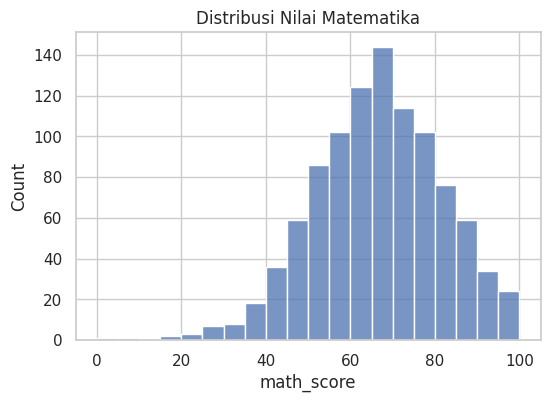

In [ ]:
# =========================
# 6. VISUAKISASI DATA
# =========================
# Cari otomatis kolom math
math_col = [col for col in df.columns if 'math' in col][0]


# Pastikan numerik
df[math_col] = pd.to_numeric(df[math_col], errors='coerce')

# Hapus NaN
df = df.dropna()

# Histogram
plt.figure(figsize=(6,4))
sns.histplot(data=df, x=math_col, bins=20)
plt.title("Distribusi Nilai Matematika")
plt.show()

# Label
df['label'] = df[math_col].apply(lambda x: 1 if x >= 70 else 0)

Dilakukan visualisasi distribusi nilai matematika menggunakan histogram.
Terlihat bahwa nilai siswa tersebar dari nilai rendah hingga tinggi.



In [ ]:
# =========================
# 7. HANDLE MISSING VALUE
# =========================
df = df.dropna()

In [ ]:
# =========================
# 8. ENCODING DATA
# =========================
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

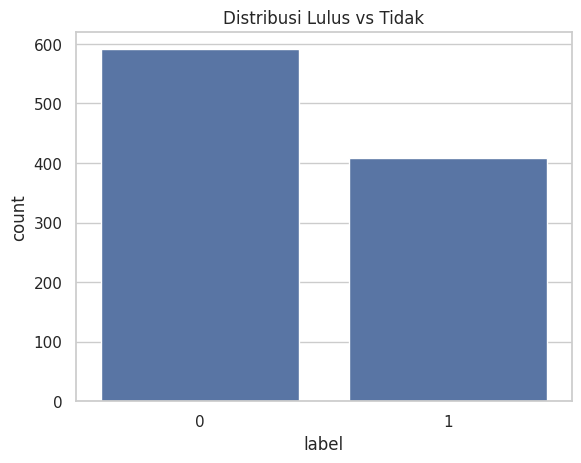

In [ ]:
# =========================
# 9. BUAT LABEL
# =========================
df['label'] = df[math_col].apply(lambda x: 1 if x >= 70 else 0)

# Visualisasi label
sns.countplot(x='label', data=df)
plt.title("Distribusi Lulus vs Tidak")
plt.show()

Dengan dibuat kolom baru yaitu label yang berisi:
*   1 → jika nilai matematika ≥ 70 (lulus)
*   0 → jika nilai < 70 (tidak lulus)

Sehingga data siswa dapat langsung diklasifikasikan berdasarkan nilai matematika.

In [ ]:
# =========================
# 10. FITUR & TARGET
# =========================
# X berisi semua kolom kecuali label
# y berisi label sebagai target
X = df.drop(['label'], axis=1)
y = df['label']

Fitur (X) berisi semua variabel seperti gender, lunch, dan nilai lainnya.
Target (y) adalah label yang menunjukkan apakah siswa lulus atau tidak.

In [ ]:
# =========================
# 11. SPLIT DATA
# =========================
# Membagi data menjadi 80% training dan 20% testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Data dibagi menjadi:
*   80% data training
*   20% data testing

Sehingga model dapat belajar dari sebagian data dan diuji pada data lainnya.

In [ ]:
# =========================
# 12. SCALING
# =========================
# Menyamakan skala data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Dilakukan scaling agar semua data memiliki skala yang sama.
Hal ini penting karena perbedaan skala dapat mempengaruhi kinerja model.

In [ ]:
# =========================
# 13. MODEL
# =========================
# Menggunakan Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Digunakan model Random Forest.
Model ini menggabungkan banyak decision tree sehingga lebih stabil dalam melakukan prediksi.

In [ ]:
# =========================
# 14. PREDIKSI
# =========================
y_pred = model.predict(X_test)

Model digunakan untuk memprediksi data testing.
Hasilnya berupa klasifikasi apakah siswa termasuk lulus atau tidak.

In [ ]:
# =========================
# 15. EVALUASI
# =========================
from sklearn.metrics import accuracy_score, classification_report

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       122
           1       1.00      1.00      1.00        78

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



Dilakukan evaluasi menggunakan akurasi.
Jika akurasi tinggi, berarti model mampu memprediksi dengan baik.

Classification report juga menunjukkan:
*   Precision
*   Recall
*   f1-score

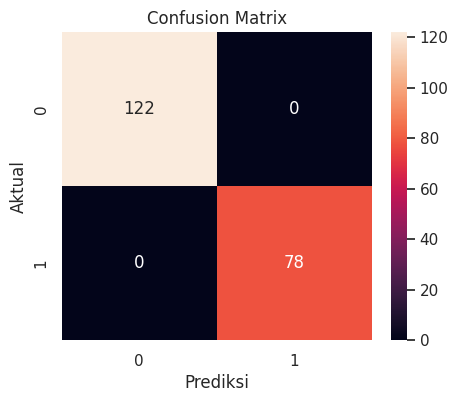

In [ ]:

# =========================
# 16. CONFUSION MATRIX
# =========================
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

Confusion matrix menunjukkan jumlah:
*   Prediksi benar (lulus & tidak lulus)
*   Prediksi salah

Sehingga dapat dilihat performa model secara lebih detail.

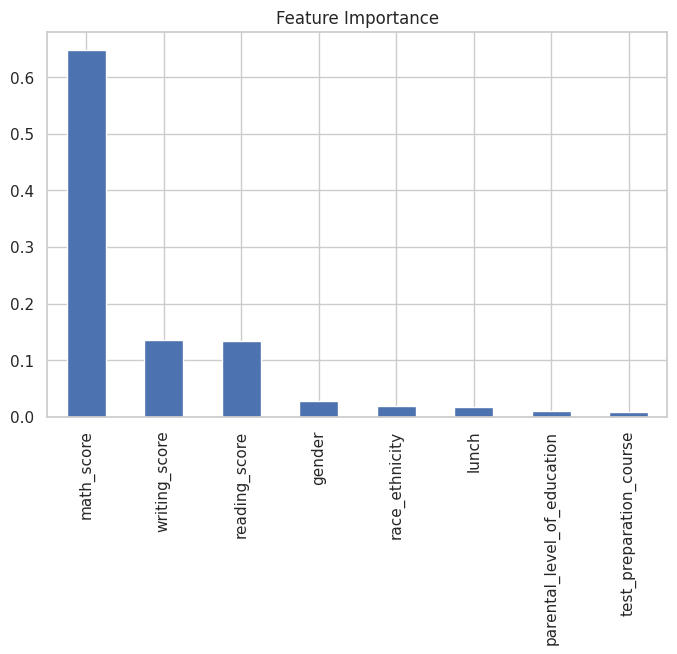

In [ ]:
# =========================
# 17. FEATURE IMPORTANCE
# =========================
import pandas as pd

importances = model.feature_importances_
features = df.drop(['label'], axis=1).columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

Dari hasil feature importance terlihat bahwa:
*   Nilai seperti reading score dan writing score biasanya memiliki pengaruh besar
*   Faktor lain seperti gender atau lunch memiliki pengaruh yang lebih kecil

Sehingga dapat disimpulkan bahwa kemampuan akademik saling berkaitan.